## Set-up

Necessary imports and helper functions

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp -r /content/drive/MyDrive/PAM/llava /content/

In [3]:
!cp -r /content/drive/MyDrive/PAM/sam2/sam2 /content/

In [4]:
!cp -r /content/drive/MyDrive/PAM/notebooks/images /content/

In [5]:
!cp /content/drive/MyDrive/PAM/notebooks/mask_vis_tools.py /content/

In [6]:
!pip install hydra-core
!pip install iopath

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=b8e1a938c75b234d8e96b08031c81c5adcd04963a1189d258f8988ce5bffad6d
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built iopath


In [7]:
!pip uninstall -y transformers tokenizers
!pip install transformers==4.39.3 tokenizers==0.15.2 sentencepiece

Found existing installation: transformers 5.13.1
Uninstalling transformers-5.13.1:
  Successfully uninstalled transformers-5.13.1
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 116.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you hav

In [8]:
import json
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
from PIL import Image
from typing import Dict, Optional, Sequence, List
import hydra

from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN, DEFAULT_IM_START_TOKEN, DEFAULT_IM_END_TOKEN
from llava.conversation import conv_templates, SeparatorStyle
from llava.model.builder import load_pretrained_model
from llava.utils import disable_torch_init
from llava.mm_utils import tokenizer_image_token, process_images, get_model_name_from_path
from mask_vis_tools import save_mask, save_box, save_points

torch.cuda.empty_cache()

Please install pyav to use video processing functions.


/content/sam2/modeling/sam/transformer.py:23: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/content/llava/model/multimodal_resampler/modules.py:20: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Define Task Modes

In [37]:
task_modes = {
    "brief_cap_en": "<image>\nProvide a concise caption for this subject.",
    "brief_cap_ch": "<image>\n对该目标对象提供一个概括的描述",
    "detail_cap_en": "<image>\nProvide a comprehensive and detailed description of the object within the selected segmentation region. Only describe the content inside the specified region and ignore other areas of the image.", #"<image>\nProvide a comprehensive and detailed description for this subject.",
    "detail_cap_ch": "<image>\n对该目标对象提供一个全面且详细的描述",
    "recognize_en": "<image>\nClassify this subject and provide its label.",
    "recognize_ch": "<image>\n对该目标对象进行分类并提供标签",
    "explain_en": "<image>\nClassify this subject and provide the label and its definition.",
    "explain_ch": "<image>\n对该目标对象进行分类并提供标签和名词功能解释"
}

Load PAM Model

In [10]:
from huggingface_hub import snapshot_download

model_dir = snapshot_download(
    repo_id="Perceive-Anything/PAM-3B",
    allow_patterns="PAM-3B/*"
)

print(model_dir)

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

trainer_state.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

zero_to_fp32.py: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/root/.cache/huggingface/hub/models--Perceive-Anything--PAM-3B/snapshots/3f1360bb804b9b4d0bd7e66256593e7b0df554e1


In [11]:
device = "cuda:0"
model_path = os.path.join(model_dir, "PAM-3B")
#model_path = "Perceive-Anything/PAM-3B"

tokenizer, model, image_processor, context_len = load_pretrained_model(
    model_path=model_path,
    model_base=None,
    model_name=get_model_name_from_path(model_path),
    multimodal=True,
    torch_dtype="bfloat16", # bfloat16, float16
    device_map="cuda",
    attn_implementation="eager"
)
model.to(device)

temperature = 0.1
top_p = None
num_beams = 1

Loaded PAM model: /root/.cache/huggingface/hub/models--Perceive-Anything--PAM-3B/snapshots/3f1360bb804b9b4d0bd7e66256593e7b0df554e1/PAM-3B


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
You are using a model of type qwen2 to instantiate a model of type llava_qwen. This is not supported for all configurations of models and can yield errors.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of the model checkpoint at /root/.cache/huggingface/hub/models--Perceive-Anything--PAM-3B/snapshots/3f1360bb804b9b4d0bd7e66256593e7b0df554e1/PAM-3B were not used when initializing LlavaQwenForCausalLM: ['model.vision_tower.sam2_model_predictor.image_encoder.neck.convs.0.conv.bias', 'model.vision_tower.sam2_model_predictor.image_encoder.neck.convs.0.conv.weight', 'model.vision_tower.sam2_model_predictor.image_encoder.neck.convs.1.conv.bias', 'model.vision_tower.sam2_model_predictor.image_encoder.neck.convs.1.conv.weight', 'model.vision_tower.sam2_model_predictor.image_encoder.neck.convs.2.conv.bias', 'model.vision_tower.sam2_model_predictor.image_encoder.neck.convs.2.conv.weight', 'model.vision_tower.sam2_model_predictor.image_encoder.neck.convs.3.conv.bias', 'model.vision_tower.sam2_model_predictor.image_encoder.neck.convs.3.conv.weight', 'model.vision_tower.sam2_model_predictor.image_encoder.trunk.blocks.0.attn.proj.bias', 'model.vision_tower.sam2_model_predictor.image_en

Model Class: LlavaQwenForCausalLM


Example Image

(448, 684, 3)


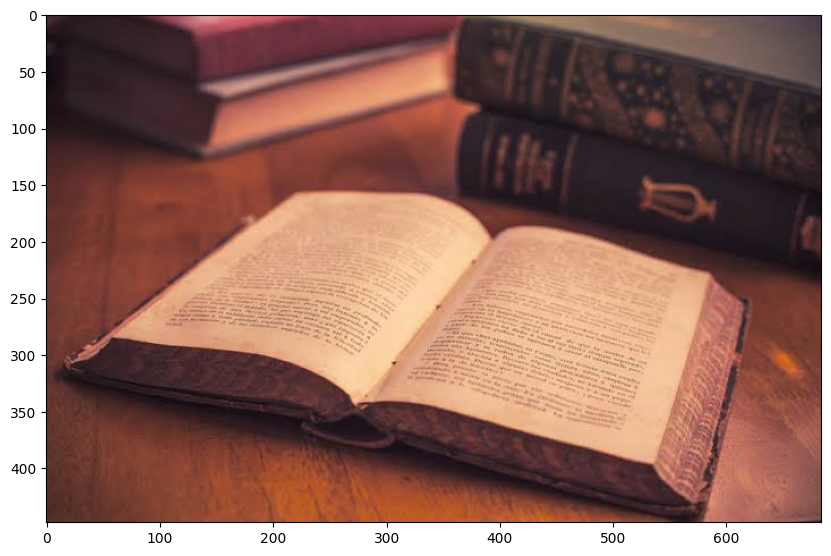

In [51]:
image = 'images/book.jpeg'
image_np = Image.open(image)
image_np = np.array(image_np.convert("RGB"))
print(image_np.shape)
plt.figure(figsize=(10, 10))
plt.imshow(image_np)
plt.axis('on')
plt.show()

Specifying a specific object with a box. The model takes a box as input, provided in xyxy format.

In [52]:
task_prompt = task_modes["detail_cap_en"]

conv = conv_templates["qwen_2"].copy()
conv.append_message(conv.roles[0], task_prompt)
conv.append_message(conv.roles[1], None)
prompt = conv.get_prompt()
input_ids = tokenizer_image_token(prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt').unsqueeze(0).to(device)

bbox_xywh = [0, 0, 684, 448]
x1, y1 = int(bbox_xywh[0]), int(bbox_xywh[1])
x2, y2 = int(bbox_xywh[0] + bbox_xywh[2]), int(bbox_xywh[1] + bbox_xywh[3])
bbox_xyxy = [x1, y1, x2, y2]
visual_prompts = bbox_xyxy
vp_labels = None

Generate semantic outputs and mask outputs.

Prediction:  The image shows a wooden table with a smooth surface.


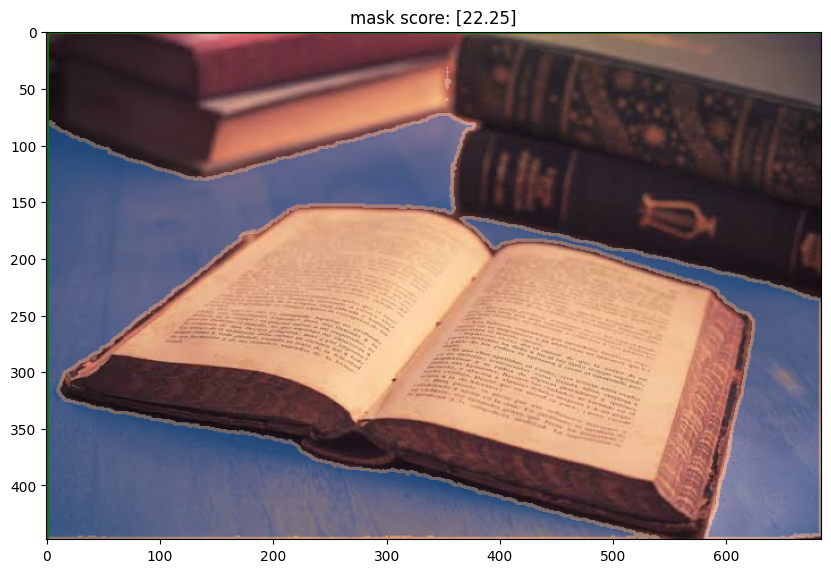

In [54]:
with torch.inference_mode():
    output_ids, all_masks_logits, all_scores = model.generate(
        input_ids,
        images=[[image]],
        visual_prompts=[visual_prompts],
        vp_labels=[vp_labels],
        types=['image'],
        do_sample=True if temperature > 0 else False,
        temperature=temperature,
        top_p=top_p,
        num_beams=num_beams,
        max_new_tokens=512,
        use_cache=True)

outputs = tokenizer.batch_decode(output_ids, skip_special_tokens=True)[0].strip()

print("Prediction: ", outputs)

for _, (img, vps, labels, masks) in enumerate(zip([image], [visual_prompts], [vp_labels], all_masks_logits)):
    img = Image.open(img).convert('RGB')
    img = np.array(img)
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(img)
    ax.set_title(f"mask score: {all_scores[0][0]}")
    for i, mask in enumerate((masks[0] > 0.0).cpu().numpy()):
        save_mask(mask, ax, borders=True)
    save_box(vps, ax)
    plt.axis('on')
    #plt.savefig("book-imp.png")
    plt.show()